<a href="https://colab.research.google.com/github/youma-code/qqq/blob/main/1.0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import time


# ======================
# データ取得
# ======================
ticker = "AAPL"
start_date = "2020-01-01"
end_date = pd.to_datetime("today").strftime("%Y-%m-%d")

def download_data(ticker, start, end):
    for _ in range(5):
        df = yf.download(ticker, start=start, end=end)
        if not df.empty:
            return df
        time.sleep(3)
    return pd.DataFrame()

df = download_data(ticker, start_date, end_date)

# Handle potential MultiIndex from yfinance to ensure df['Close'] is a Series
if isinstance(df.columns, pd.MultiIndex):
    df = df[['Close', 'High', 'Low', 'Volume']].droplevel(level=1, axis=1)
else:
    df = df[['Close', 'High', 'Low', 'Volume']].copy() # Use .copy() to avoid SettingWithCopyWarning
df.columns = ['Close', 'High', 'Low', 'Volume'] # Ensure column names are simple strings
df.dropna(inplace=True)

# ======================
# 特徴量作成
# ======================

# SMA
df['SMA_5'] = df['Close'].rolling(5).mean()
df['SMA_25'] = df['Close'].rolling(25).mean()
df['SMA_DIFF'] = df['SMA_5'] - df['SMA_25']
df['SMA_RATIO'] = df['SMA_5'] / df['SMA_25']

# Target
future_max = df['Close'].shift(-1).rolling(3).max()
df['Target'] = ((future_max / df['Close'] - 1) > 0.0075).astype(int)

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# MACD
ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD'] = ema12 - ema26
df['Signal_Line'] = df['MACD'].ewm(span=9).mean()
df['MACD_Hist'] = df['MACD'] - df['Signal_Line']

df['Daily_Return'] = df['Close'].pct_change()
df['Volatility_Short'] = df['Daily_Return'].rolling(5).std()


# ATR
tr = pd.concat([
    df['High'] - df['Low'],
    abs(df['High'] - df['Close'].shift()),
    abs(df['Low'] - df['Close'].shift())
], axis=1).max(axis=1)

df['ATR'] = tr.rolling(14).mean()

# ======================
# ADX（トレンド強さ）
# ======================

window = 14

high = df['High']
low = df['Low']
close = df['Close']

plus_dm = high.diff()
minus_dm = -low.diff()

plus_dm[plus_dm < 0] = 0
minus_dm[minus_dm < 0] = 0

tr = pd.concat([
    high - low,
    (high - close.shift()).abs(),
    (low - close.shift()).abs()
], axis=1).max(axis=1)

atr = tr.rolling(window).mean()

plus_di = 100 * (plus_dm.rolling(window).mean() / atr)
minus_di = 100 * (minus_dm.rolling(window).mean() / atr)

dx = (abs(plus_di - minus_di) / (plus_di + minus_di)) * 100

df['ADX'] = dx.rolling(window).mean()

# ボリンジャー
# Ensure ma and std are Series by using .squeeze() if they result in single-column DataFrames
ma = df['Close'].rolling(20).mean().squeeze()
std = df['Close'].rolling(20).std().squeeze()

df['Upper_BB'] = ma + 2 * std
df['Lower_BB'] = ma - 2 * std
df['BB_Width'] = (df['Upper_BB'] - df['Lower_BB']) / ma

# ラグ
for lag in range(1, 6):
    df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)

# 最後にNaN削除
df.dropna(inplace=True)

print("セル1完了:", df.shape)

/tmp/ipykernel_18148/3527103283.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed

セル1完了: (1559, 25)


In [2]:
# ======================
# 特徴量リスト（固定）
# ======================

features = [
    'SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO',
    'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
    'ATR',
    'Upper_BB', 'Lower_BB', 'BB_Width',
    'Volatility_Short',
    'ADX'  # ←これ追加
]
# ラグ特徴量（セル1で作ったやつに対応）
for lag in range(1, 6):
    features.append(f'Close_Lag_{lag}')

# 存在しない列があったら弾く（安全対策）
features = [f for f in features if f in df.columns]

print("使用特徴量数:", len(features))
print(features[:10])

使用特徴量数: 19
['SMA_5', 'SMA_25', 'SMA_DIFF', 'SMA_RATIO', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist', 'ATR', 'Upper_BB']


In [3]:
# ======================
# X, y 作成
# ======================

# 念のためチェック
assert 'Target' in df.columns, "Target列が存在しません"

# Xとy
X = df[features].copy()
y = df['Target'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target分布:")
print(y.value_counts(normalize=True))

X shape: (1559, 19)
y shape: (1559,)
Target分布:
Target
0    0.516357
1    0.483643
Name: proportion, dtype: float64


In [4]:
X = df[features]
y = df['Target']
print(f"X and y defined. Feature matrix shape: {X.shape}")

X and y defined. Feature matrix shape: (1559, 19)


In [5]:
# ======================
# 時系列分割
# ======================

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test  = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test  = y.iloc[split_index:].copy()

print("Train期間:", X_train.index.min(), "→", X_train.index.max())
print("Test期間 :", X_test.index.min(), "→", X_test.index.max())

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train期間: 2020-02-11 00:00:00 → 2025-01-27 00:00:00
Test期間 : 2025-01-28 00:00:00 → 2026-04-24 00:00:00
Train size: (1247, 19)
Test size : (312, 19)


In [6]:
# ======================
# SMOTE（訓練データのみ）
# ======================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE: Target
1    632
0    615
Name: count, dtype: int64
After SMOTE:
Target
1    632
0    632
Name: count, dtype: int64


In [7]:
# ======================
# RandomForest チューニング
# ======================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# モデル定義
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# パラメータ範囲
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# チューニング
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 最初は軽めでOK（後で増やせる）
    scoring='f1',             # 不均衡データ向け
    cv=3,                     # 時系列じゃない簡易CV（後で改善）
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ使う）
random_search_rf.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_rf_tuned = random_search_rf.best_estimator_

print("Best params:", random_search_rf.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 335}


In [8]:
# ======================
# XGBoost チューニング
# ======================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# モデル定義
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# パラメータ範囲
param_dist_xgb = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

# チューニング
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,          # 最初は軽め
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 学習（SMOTE後データ）
random_search_xgb.fit(X_train_resampled, y_train_resampled)

# 最適モデル
model_xgb_tuned = random_search_xgb.best_estimator_

print("Best params:", random_search_xgb.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'colsample_bytree': np.float64(0.8650089137415928), 'gamma': np.float64(0.15585553804470548), 'learning_rate': np.float64(0.11401360423556216), 'max_depth': 6, 'n_estimators': 409, 'reg_alpha': np.float64(0.01565664622777929), 'reg_lambda': np.float64(1.7634271618924977), 'subsample': np.float64(0.7799016533479063)}


In [9]:
# ======================
# 予測確率の取得
# ======================

# RandomForest
proba_class1_rf = model_rf_tuned.predict_proba(X_test)[:, 1]

# XGBoost
proba_class1_xgb = model_xgb_tuned.predict_proba(X_test)[:, 1]

# 確認
print("RF proba shape:", proba_class1_rf.shape)
print("XGB proba shape:", proba_class1_xgb.shape)

RF proba shape: (312,)
XGB proba shape: (312,)


In [10]:
# ======================
# 戦略A・Bの定義
# ======================

# 閾値（あとで調整可能）
threshold = 0.6

# --- 戦略A：AND条件（両モデルが強気） ---
strategy_A = (
    (proba_class1_rf > threshold) &
    (proba_class1_xgb > threshold)
).astype(int)

# --- 戦略B：XGBoost重視 ---
strategy_B = (
    (proba_class1_xgb > threshold)
).astype(int)

# 確認
print("Strategy A trades:", strategy_A.sum())
print("Strategy B trades:", strategy_B.sum())

Strategy A trades: 19
Strategy B trades: 90


In [11]:
# ======================
# バックテスト関数（統一版）
# ======================

def run_backtest(df, X_test, signals, initial_balance=100000, risk_per_trade=0.02):

    # --- テスト期間のデータだけ使う ---
    df_bt = df.loc[X_test.index].copy()

    # --- 必須列チェック ---
    required_cols = ['Close', 'ATR']
    df_bt = df_bt.dropna(subset=required_cols)

    # signalsも同じindexに揃える
    signals = signals.loc[df_bt.index]

    # --- 初期化 ---
    balance = initial_balance
    equity_curve = []
    position = 0
    entry_price = 0
    trade_count = 0
    win_count = 0

    for i in range(len(df_bt) - 1):
        row = df_bt.iloc[i]
        next_row = df_bt.iloc[i + 1]

        signal = signals.iloc[i]

        # ======================
        # エントリー
        # ======================
        if position == 0 and signal == 1:

            # ATR-based position sizing
            atr = row['ATR']
            if pd.isna(atr) or atr == 0:
                continue

            risk_amount = balance * risk_per_trade
            stop_loss_distance = atr * 2

            position_size = risk_amount / stop_loss_distance

            entry_price = next_row['Close']
            position = position_size
            trade_count += 1

        # ======================
        # ポジション保有中
        # ======================
        elif position > 0:

            current_price = next_row['Close']

            # ストップロス
            stop_price = entry_price - (row['ATR'] * 2)

            # 利確（リスクリワード 1:2）
            take_profit_price = entry_price + (row['ATR'] * 4)

            exit_flag = False

            if current_price <= stop_price:
                exit_flag = True
            elif current_price >= take_profit_price:
                exit_flag = True

            if exit_flag:
                pnl = (current_price - entry_price) * position
                balance += pnl

                if pnl > 0:
                    win_count += 1

                position = 0

        equity_curve.append(balance)

    # --- 最後のポジション強制決済 ---
    if position > 0:
        final_price = df_bt.iloc[-1]['Close']
        pnl = (final_price - entry_price) * position
        balance += pnl

        if pnl > 0:
            win_count += 1

    # --- 結果まとめ ---
    win_rate = (win_count / trade_count * 100) if trade_count > 0 else 0
    total_return = (balance / initial_balance - 1) * 100

    results = {
        'Final Balance': balance,
        'Total Return (%)': total_return,
        'Total Trades': trade_count,
        'Win Rate (%)': win_rate
    }

    return results, equity_curve

In [12]:
# ======================
# バックテスト実行
# ======================

import pandas as pd

# signalsをSeriesに変換（超重要）
signals_A = pd.Series(strategy_A, index=X_test.index)
signals_B = pd.Series(strategy_B, index=X_test.index)

# --- 戦略A ---
results_A, equity_A = run_backtest(df, X_test, signals_A)

# --- 戦略B ---
results_B, equity_B = run_backtest(df, X_test, signals_B)

# 結果表示
print("===== Strategy A =====")
for k, v in results_A.items():
    print(f"{k}: {v}")

print("\n===== Strategy B =====")
for k, v in results_B.items():
    print(f"{k}: {v}")

===== Strategy A =====
Final Balance: 110207.68283131806
Total Return (%): 10.207682831318055
Total Trades: 4
Win Rate (%): 75.0

===== Strategy B =====
Final Balance: 108444.62982884809
Total Return (%): 8.444629828848083
Total Trades: 11
Win Rate (%): 45.45454545454545


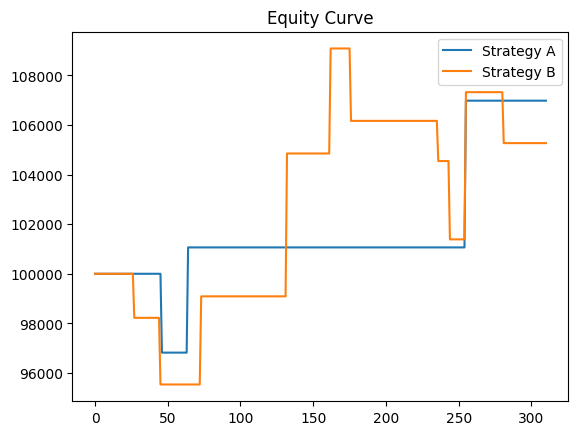

In [13]:
import matplotlib.pyplot as plt

plt.plot(equity_A, label="Strategy A")
plt.plot(equity_B, label="Strategy B")

plt.legend()
plt.title("Equity Curve")
plt.show()

In [15]:
# ======================
# Optunaのインストール
# ======================
!pip install optuna

import optuna
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# ======================
# 評価指標
# ======================
def calc_metrics(equity):
    equity = np.array(equity)

    returns = np.diff(equity)
    gains = returns[returns > 0].sum()
    losses = -returns[returns < 0].sum() + 1e-9

    profit_factor = gains / losses

    peak = np.maximum.accumulate(equity)
    dd = (equity - peak) / peak
    max_dd = abs(dd.min())

    return profit_factor, max_dd


# ======================
# Optuna
# ======================
def objective(trial):

    model_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
    }

    threshold = trial.suggest_float("threshold", 0.45, 0.7)
    adx_th = trial.suggest_int("adx_th", 10, 25)
    vol_q = trial.suggest_float("vol_q", 0.5, 0.9)

    tscv = TimeSeriesSplit(n_splits=3)

    scores = []

    for train_idx, val_idx in tscv.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

        model = XGBClassifier(**model_params, random_state=42, eval_metric='logloss')
        model.fit(X_train_res, y_train_res)

        proba = model.predict_proba(X_val)[:, 1]

        df_slice = df.loc[X_val.index].copy()
        df_slice["proba"] = proba

        vol_threshold = df_slice["Volatility_Short"].quantile(vol_q)

        signals = (
            (df_slice["proba"] > threshold) &
            (df_slice["ADX"] > adx_th) &
            (df_slice["Volatility_Short"] > vol_threshold)
        ).astype(int)

        results, equity = run_backtest(df, X_val, signals)

        # ======================
        # metrics
        # ======================
        trades = results["Total Trades"]
        winrate = results["Win Rate (%)"] / 100

        equity = np.array(equity)
        returns = np.diff(equity) / equity[:-1]

        # PF（簡易）
        gross_profit = np.sum(returns[returns > 0])
        gross_loss = -np.sum(returns[returns < 0]) + 1e-9
        pf = gross_profit / gross_loss

        dd = np.min(equity / np.maximum.accumulate(equity) - 1)

        # ======================
        # スコア（重要）
        # ======================
        score = (
            winrate * 0.4 +
            np.log1p(pf) * 0.3 +
            (1 + dd) * 0.3   # DDはマイナスなので補正
        )

        scores.append(score)

    return np.mean(scores)


# ======================
# 実行
# ======================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.3 MB/s eta 0:00:00


[I 2026-04-25 04:46:46,837] A new study created in memory with name: no-name-ff8e01c6-d418-48ab-aadd-9896ff72e57b
[I 2026-04-25 04:46:47,869] Trial 0 finished with value: 0.5303742737841292 and parameters: {'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.19069906153746166, 'subsample': 0.6794467282005223, 'colsample_bytree': 0.6577473526389592, 'gamma': 0.3114866350798173, 'reg_alpha': 0.38222080809565834, 'reg_lambda': 1.328975503751017, 'threshold': 0.6416497429507605, 'adx_th': 22, 'vol_q': 0.7981191059621553}. Best is trial 0 with value: 0.5303742737841292.
[I 2026-04-25 04:46:48,833] Trial 1 finished with value: 0.6466080806172635 and parameters: {'n_estimators': 139, 'max_depth': 5, 'learning_rate': 0.18581327011675958, 'subsample': 0.9541081014678342, 'colsample_bytree': 0.9728076795187928, 'gamma': 0.3438425833944928, 'reg_alpha': 0.48078627870197016, 'reg_lambda': 1.608133606362676, 'threshold': 0.49246238307423157, 'adx_th': 16, 'vol_q': 0.8996651221317815}. Best is t

{'n_estimators': 106, 'max_depth': 9, 'learning_rate': 0.18124892517632946, 'subsample': 0.8343883572027586, 'colsample_bytree': 0.6083906068445171, 'gamma': 0.19817850560364708, 'reg_alpha': 0.4454542024710449, 'reg_lambda': 0.7679023644985573, 'threshold': 0.5798915503225239, 'adx_th': 22, 'vol_q': 0.5904850788097367}


In [16]:
print("proba exists:", "proba" in globals())

proba exists: False


In [17]:
best_params = study.best_params
print(best_params)  # 念のため確認

model_params = {
    k: best_params[k] for k in [
        'n_estimators','max_depth','learning_rate',
        'subsample','colsample_bytree',
        'gamma','reg_alpha','reg_lambda'
    ]
}

strategy_params = {
    "threshold": best_params["threshold"],
    "adx_th": best_params["adx_th"],
    "vol_q": best_params["vol_q"]
}

{'n_estimators': 106, 'max_depth': 9, 'learning_rate': 0.18124892517632946, 'subsample': 0.8343883572027586, 'colsample_bytree': 0.6083906068445171, 'gamma': 0.19817850560364708, 'reg_alpha': 0.4454542024710449, 'reg_lambda': 0.7679023644985573, 'threshold': 0.5798915503225239, 'adx_th': 22, 'vol_q': 0.5904850788097367}


In [18]:
model = XGBClassifier(
    **model_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [19]:
# ======================
# 最終モデル + 最終バックテスト
# ======================

from xgboost import XGBClassifier

# --- Optunaの最適パラメータ取得 ---
best_params = study.best_params.copy()

# thresholdは別で使う
best_threshold = best_params.pop('threshold')

print("Best threshold:", best_threshold)
print("Best model params:", best_params)

# ======================
# モデル再学習（全訓練データ）
# ======================

# SMOTE（訓練データのみ）
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# モデル作成
final_model = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# 学習
final_model.fit(X_train_resampled, y_train_resampled)

# ======================
# 予測
# ======================

proba_final = final_model.predict_proba(X_test)[:, 1]

# ======================
# 戦略（最適threshold）
# ======================

strategy_final = (proba_final > best_threshold).astype(int)

# Series化（重要）
signals_final = pd.Series(strategy_final, index=X_test.index)

# ======================
# バックテスト
# ======================

results_final, equity_final = run_backtest(df, X_test, signals_final)

# ======================
# 結果表示
# ======================

print("===== FINAL RESULT =====")
for k, v in results_final.items():
    print(f"{k}: {v}")

Best threshold: 0.5798915503225239
Best model params: {'n_estimators': 106, 'max_depth': 9, 'learning_rate': 0.18124892517632946, 'subsample': 0.8343883572027586, 'colsample_bytree': 0.6083906068445171, 'gamma': 0.19817850560364708, 'reg_alpha': 0.4454542024710449, 'reg_lambda': 0.7679023644985573, 'adx_th': 22, 'vol_q': 0.5904850788097367}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:50:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "adx_th", "vol_q" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== FINAL RESULT =====
Final Balance: 117401.24272062126
Total Return (%): 17.40124272062127
Total Trades: 13
Win Rate (%): 53.84615384615385


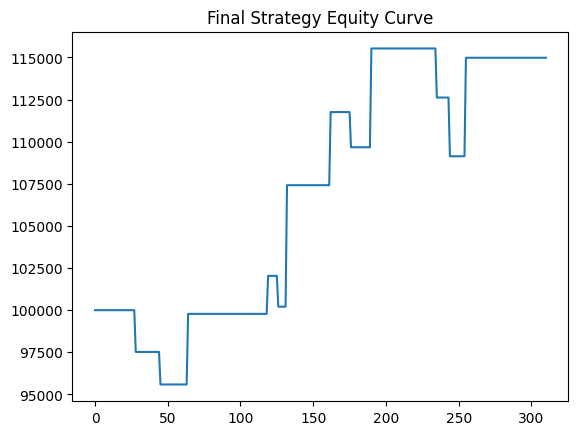

In [20]:
import matplotlib.pyplot as plt

plt.plot(equity_final)
plt.title("Final Strategy Equity Curve")
plt.show()

In [21]:
# ======================
# 時系列CVで最終戦略を検証
# ======================

from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)

results_list = []
equity_curves = []

# --- Optunaの最適パラメータ取得 (best_params はグローバルに存在すると仮定) ---
# best_params は既に study.best_params として定義されているはず
# Freshly get best_params from study to avoid prior modifications
best_params_cv = study.best_params.copy()

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n===== Fold {fold+1} ====")

    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # --- SMOTE（訓練データのみ） ---
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_cv, y_train_cv)

    # --- モデル（Optunaの最適パラメータ） ---
    # best_params_cvには'threshold', 'adx_th', 'vol_q'が含まれるので、
    # モデルパラメータから除外してXGBClassifierに渡す
    model_params_for_xgb = {k: best_params_cv[k] for k in best_params_cv if k not in [
        'threshold','adx_th','vol_q'
    ]}

    # Initialize model for each fold
    model = XGBClassifier(
        **model_params_for_xgb,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train_res, y_train_res)

    # --- 予測 ---
    proba = model.predict_proba(X_test_cv)[:, 1]

    # --- 戦略 ---
    df_slice = df.loc[X_test_cv.index].copy()
    df_slice['proba'] = proba
    # ADXとVolatility_Shortはdf_sliceに存在しない場合があるので、dfから取得
    df_slice['ADX'] = df.loc[X_test_cv.index, 'ADX']
    df_slice['Volatility_Short'] = df.loc[X_test_cv.index, 'Volatility_Short']
    # MACDとSignal_Lineは戦略には直接使用しないが、df_sliceに含める場合はここで追加
    # df_slice['MACD'] = df.loc[X_test_cv.index, 'MACD']
    # df_slice['Signal_Line'] = df.loc[X_test_cv.index, 'Signal_Line']

    vol_threshold = df_slice['Volatility_Short'].quantile(best_params_cv["vol_q"])

    signals = (
        (df_slice['proba'] > best_params_cv["threshold"]) &
        (df_slice['ADX'] > best_params_cv["adx_th"]) &
        (df_slice['Volatility_Short'] > vol_threshold)
    ).astype(int)

    # --- バックテスト ---
    results, equity = run_backtest(df, X_test_cv, signals)

    results_list.append(results)
    equity_curves.append(equity)

    print(results)

# ======================
# 結果まとめ
# ======================

df_results = pd.DataFrame(results_list)

print("\n===== CV SUMMARY ====")
print(df_results.mean())
print("\nSTD:")
print(df_results.std())


===== Fold 1 ====
{'Final Balance': np.float64(104943.7348270564), 'Total Return (%)': np.float64(4.94373482705639), 'Total Trades': 5, 'Win Rate (%)': 60.0}

===== Fold 2 ====
{'Final Balance': np.float64(101367.57163916259), 'Total Return (%)': np.float64(1.3675716391625903), 'Total Trades': 8, 'Win Rate (%)': 50.0}

===== Fold 3 ====
{'Final Balance': np.float64(103403.32180081916), 'Total Return (%)': np.float64(3.40332180081917), 'Total Trades': 7, 'Win Rate (%)': 42.857142857142854}

===== Fold 4 ====
{'Final Balance': np.float64(98904.2694729224), 'Total Return (%)': np.float64(-1.0957305270775985), 'Total Trades': 6, 'Win Rate (%)': 50.0}

===== Fold 5 ====
{'Final Balance': np.float64(111328.12201374472), 'Total Return (%)': np.float64(11.328122013744713), 'Total Trades': 5, 'Win Rate (%)': 80.0}

===== CV SUMMARY ====
Final Balance       103989.403951
Total Return (%)         3.989404
Total Trades             6.200000
Win Rate (%)            56.571429
dtype: float64

STD:
Fi

In [22]:
print('ADX' in df.columns)
print(df.columns)

True
Index(['Close', 'High', 'Low', 'Volume', 'SMA_5', 'SMA_25', 'SMA_DIFF',
       'SMA_RATIO', 'Target', 'RSI', 'MACD', 'Signal_Line', 'MACD_Hist',
       'Daily_Return', 'Volatility_Short', 'ATR', 'ADX', 'Upper_BB',
       'Lower_BB', 'BB_Width', 'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3',
       'Close_Lag_4', 'Close_Lag_5'],
      dtype='object')
